##  Principal Component Analysis (PCA)

https://youtu.be/FgakZw6K1QQ

# Examples

## Fisher’s iris dataset

Text(0.5, 0, 'Petal Length')

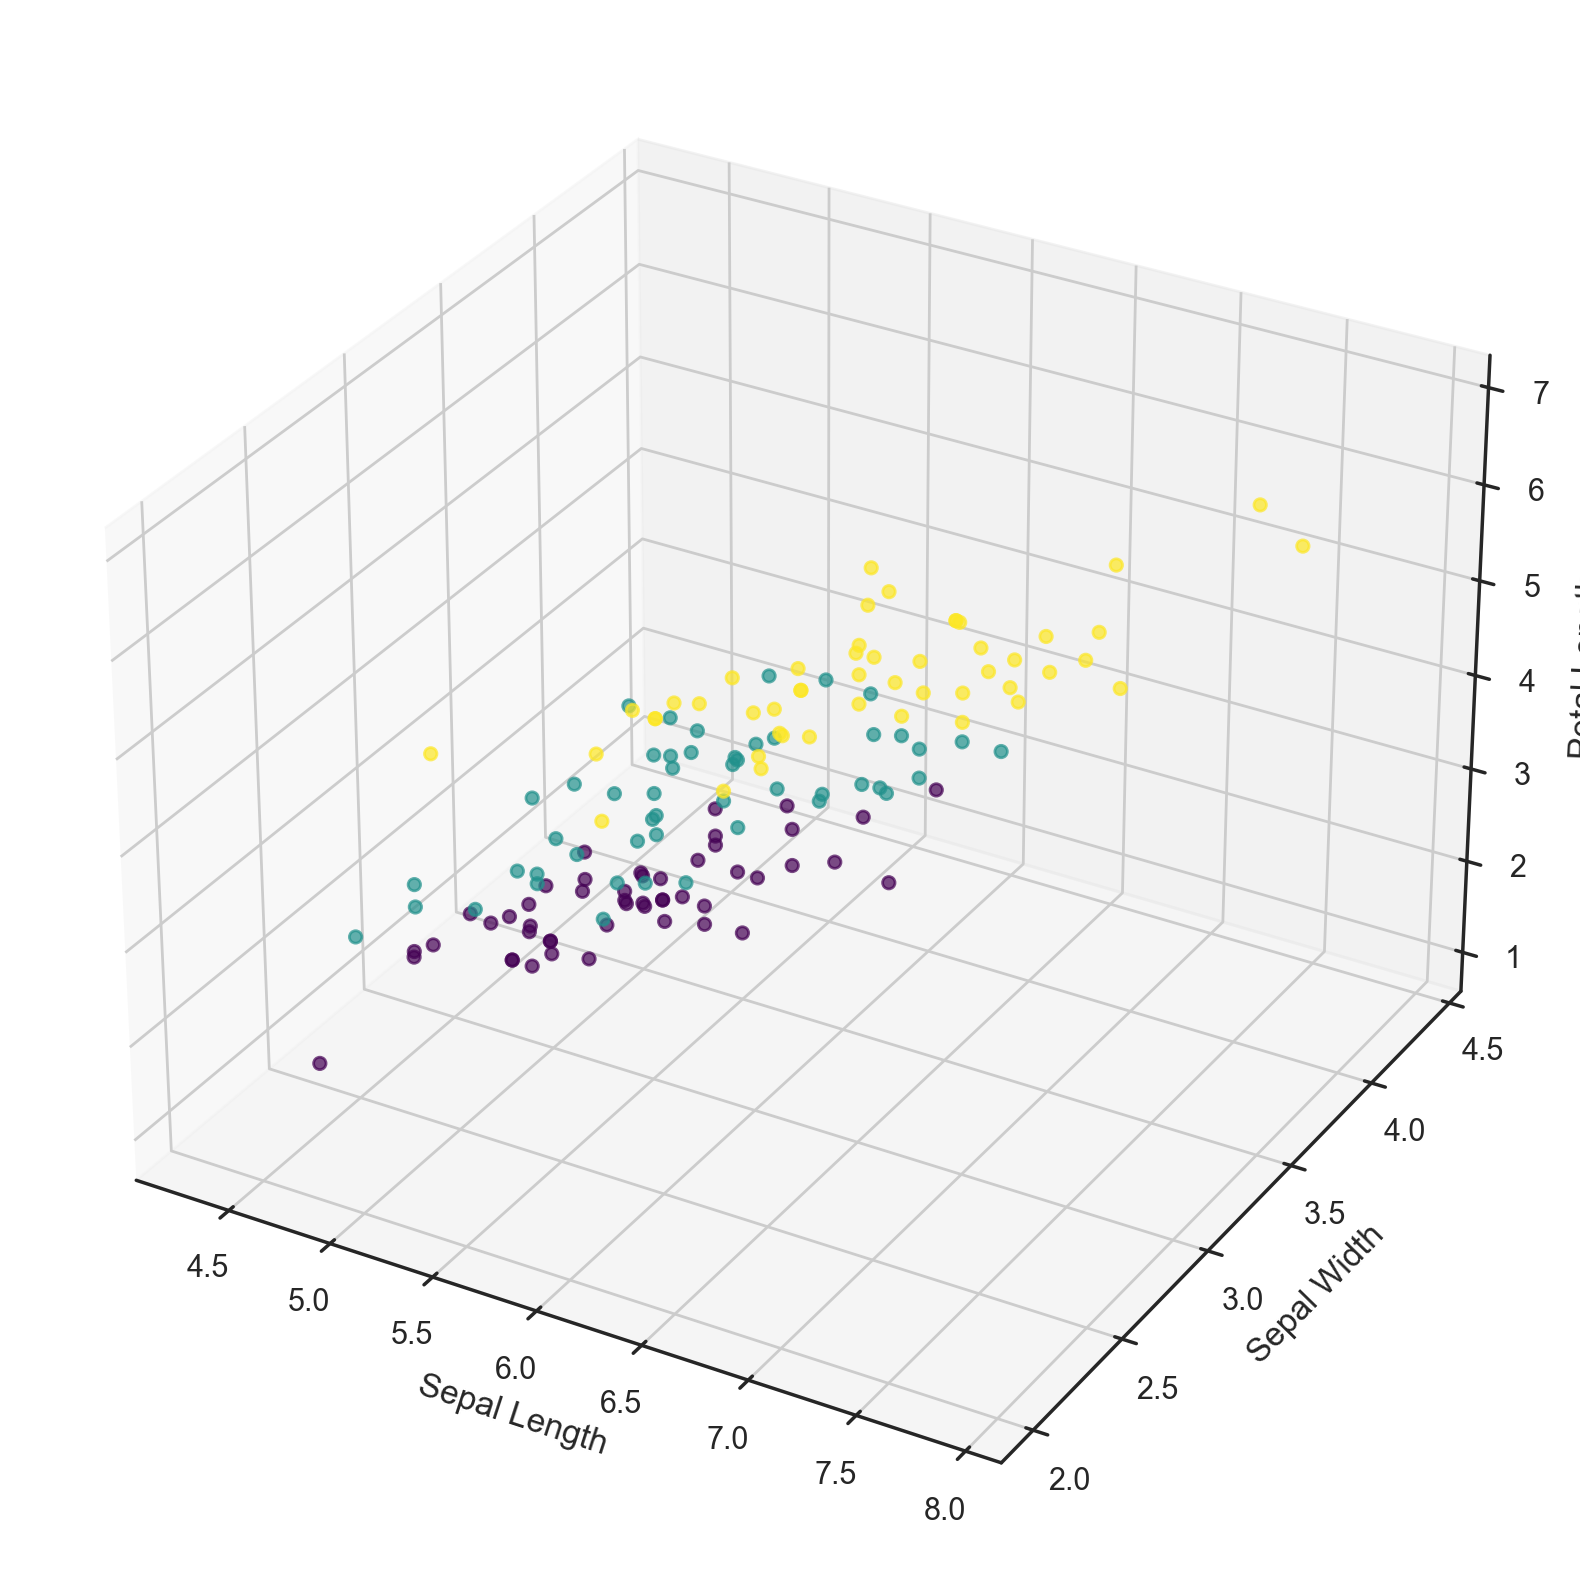

In [1]:
# Let’s start by uploading all of the essential modules and try out the iris example
#  from the scikit-learn documentation.

import numpy as np
import pandas as pd
from sklearn import datasets, decomposition

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="white")
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# load the iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# plot the dataset in 3d ignoring petal width
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X[:, 0], X[:, 1], X[:, 2],  
           c=y, cmap='viridis', alpha=0.7)
ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Petal Length')

Now let’s see how PCA will improve the results of a simple model that is not able to correctly fit all of the training data:

In [2]:
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Train, test splits

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# decision tree with depth 2
clf = DecisionTreeClassifier(max_depth=2, random_state=42)
clf.fit(X_train, y_train)
predicts = clf.predict_proba(X_test)
# print(predicts)
print("Accuracy: {:.5f}".format(accuracy_score(y_test, predicts.argmax(axis=1))))

Accuracy: 0.88889


Not quite. It's the probability that **the model assigns to each possible class**, **before knowing the true answer**.

Let's use an example.

Suppose you're predicting whether an email is spam.

The true label (`y_test`) for one email is:

```python
1   # Spam
```

The model predicts:

```python
clf.predict_proba(X_test)
```

returns

```python
[[0.30, 0.70]]
```

This means the model is saying:

* **30% chance** this email is **not spam (class 0)**
* **70% chance** this email is **spam (class 1)**

The model will therefore predict:

```python
clf.predict(X_test)
```

returns

```python
[1]
```

because 70% is larger than 30%.

---

Now compare that prediction to the actual label:

| Actual (`y_test`) | Predicted | Correct? |
| ----------------- | --------- | -------- |
| 1                 | 1         | ✅ Yes    |

In this case, the model was correct.

---

Now imagine another sample:

Actual label:

```python
0
```

Model says:

```python
[[0.10, 0.90]]
```

The model is **90% confident** the sample belongs to class 1.

So it predicts:

```python
1
```

But the true label is actually `0`.

| Actual | Predicted | Correct? |
| ------ | --------- | -------- |
| 0      | 1         | ❌ No     |

Even though the model gave **90% probability**, it was wrong.

---

### So what does `predict_proba()` mean?

It **does not** mean:

> "There is a 90% chance my prediction is correct."

It means:

> "Based on what I learned from the training data, I estimate there's a 90% probability this sample belongs to class 1."

Whether that estimate is actually correct is determined only by comparing it to the true label (`y_test`).

Think of it like a weather forecast:

* Weather app: "70% chance of rain."
* It either rains or it doesn't.

The **70%** is the model's estimate **before** the outcome is known—not a guarantee that the forecast itself is correct. The same idea applies to `predict_proba()`.


### Let’s try this again, but, this time, let’s reduce the dimensionality to 2 dimensions:

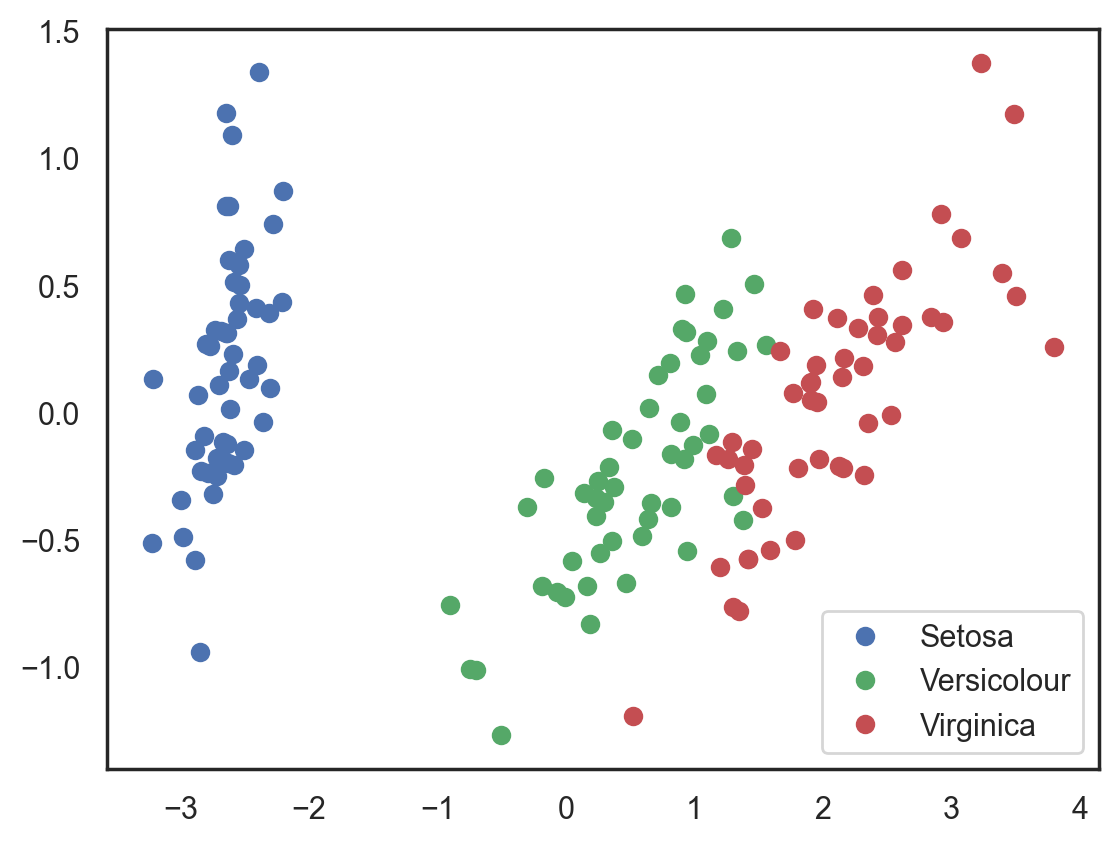

In [3]:
# Using PCA from sklearn pca

pca = decomposition.PCA(n_components=2)
X_centered = X - X.mean(axis=0)
pca.fit(X_centered)
X_pca = pca.transform(X_centered)

# X_pca

# Plotting the results of PCA
plt.plot(X_pca[y == 0, 0], X_pca[y == 0, 1], "bo", label="Setosa")
plt.plot(X_pca[y == 1, 0], X_pca[y == 1, 1], "go", label="Versicolour")
plt.plot(X_pca[y == 2, 0], X_pca[y == 2, 1], "ro", label="Virginica")
plt.legend(loc=0);

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, stratify=y, random_state=42
)
clf = DecisionTreeClassifier(max_depth=2, random_state=42)
clf.fit(X_train, y_train)
predicts = clf.predict_proba(X_test)
print("Accuracy: {:.5f}".format(accuracy_score(y_test, predicts.argmax(axis=1))))

Accuracy: 0.89474


Now let’s check out the percent of variance that can be explained by each of the selected components.

In [5]:
for i, component in enumerate(pca.components_):
    print(
        "{} component: {}% of initial variance"
    )

{} component: {}% of initial variance
{} component: {}% of initial variance


In [6]:
for i, component in enumerate(pca.components_):
    print(
        "{} component: {}% of initial variance".format(
            i + 1, round(100 * pca.explained_variance_ratio_[i], 2)
        )
    )
    print(
        " + ".join(
            "%.3f x %s" % (value, name)
            for value, name in zip(component, iris.feature_names)
        )
    )

1 component: 92.46% of initial variance
0.361 x sepal length (cm) + -0.085 x sepal width (cm) + 0.857 x petal length (cm) + 0.358 x petal width (cm)
2 component: 5.31% of initial variance
0.657 x sepal length (cm) + 0.730 x sepal width (cm) + -0.173 x petal length (cm) + -0.075 x petal width (cm)


## Handwritten numbers dataset

In [7]:
# lets look at handwritten numbers dataset from topic 3

digits = datasets.load_digits()
X = digits.data
y= digits.target

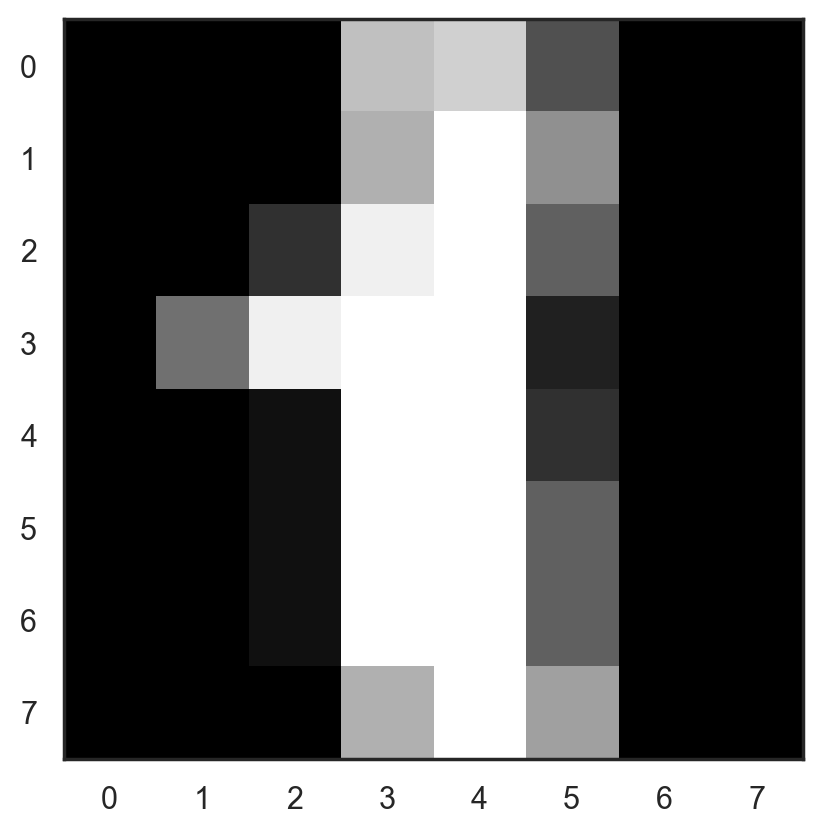

In [8]:
a= X[1].reshape([8,8])
plt.imshow(a, cmap="grey")

Let’s start by visualizing our data. Fetch the first 10 numbers. The numbers are represented by 8 x 8 matrices with the color intensity for each pixel. Every matrix is flattened into a vector of 64 numbers, so we get the feature version of the data.

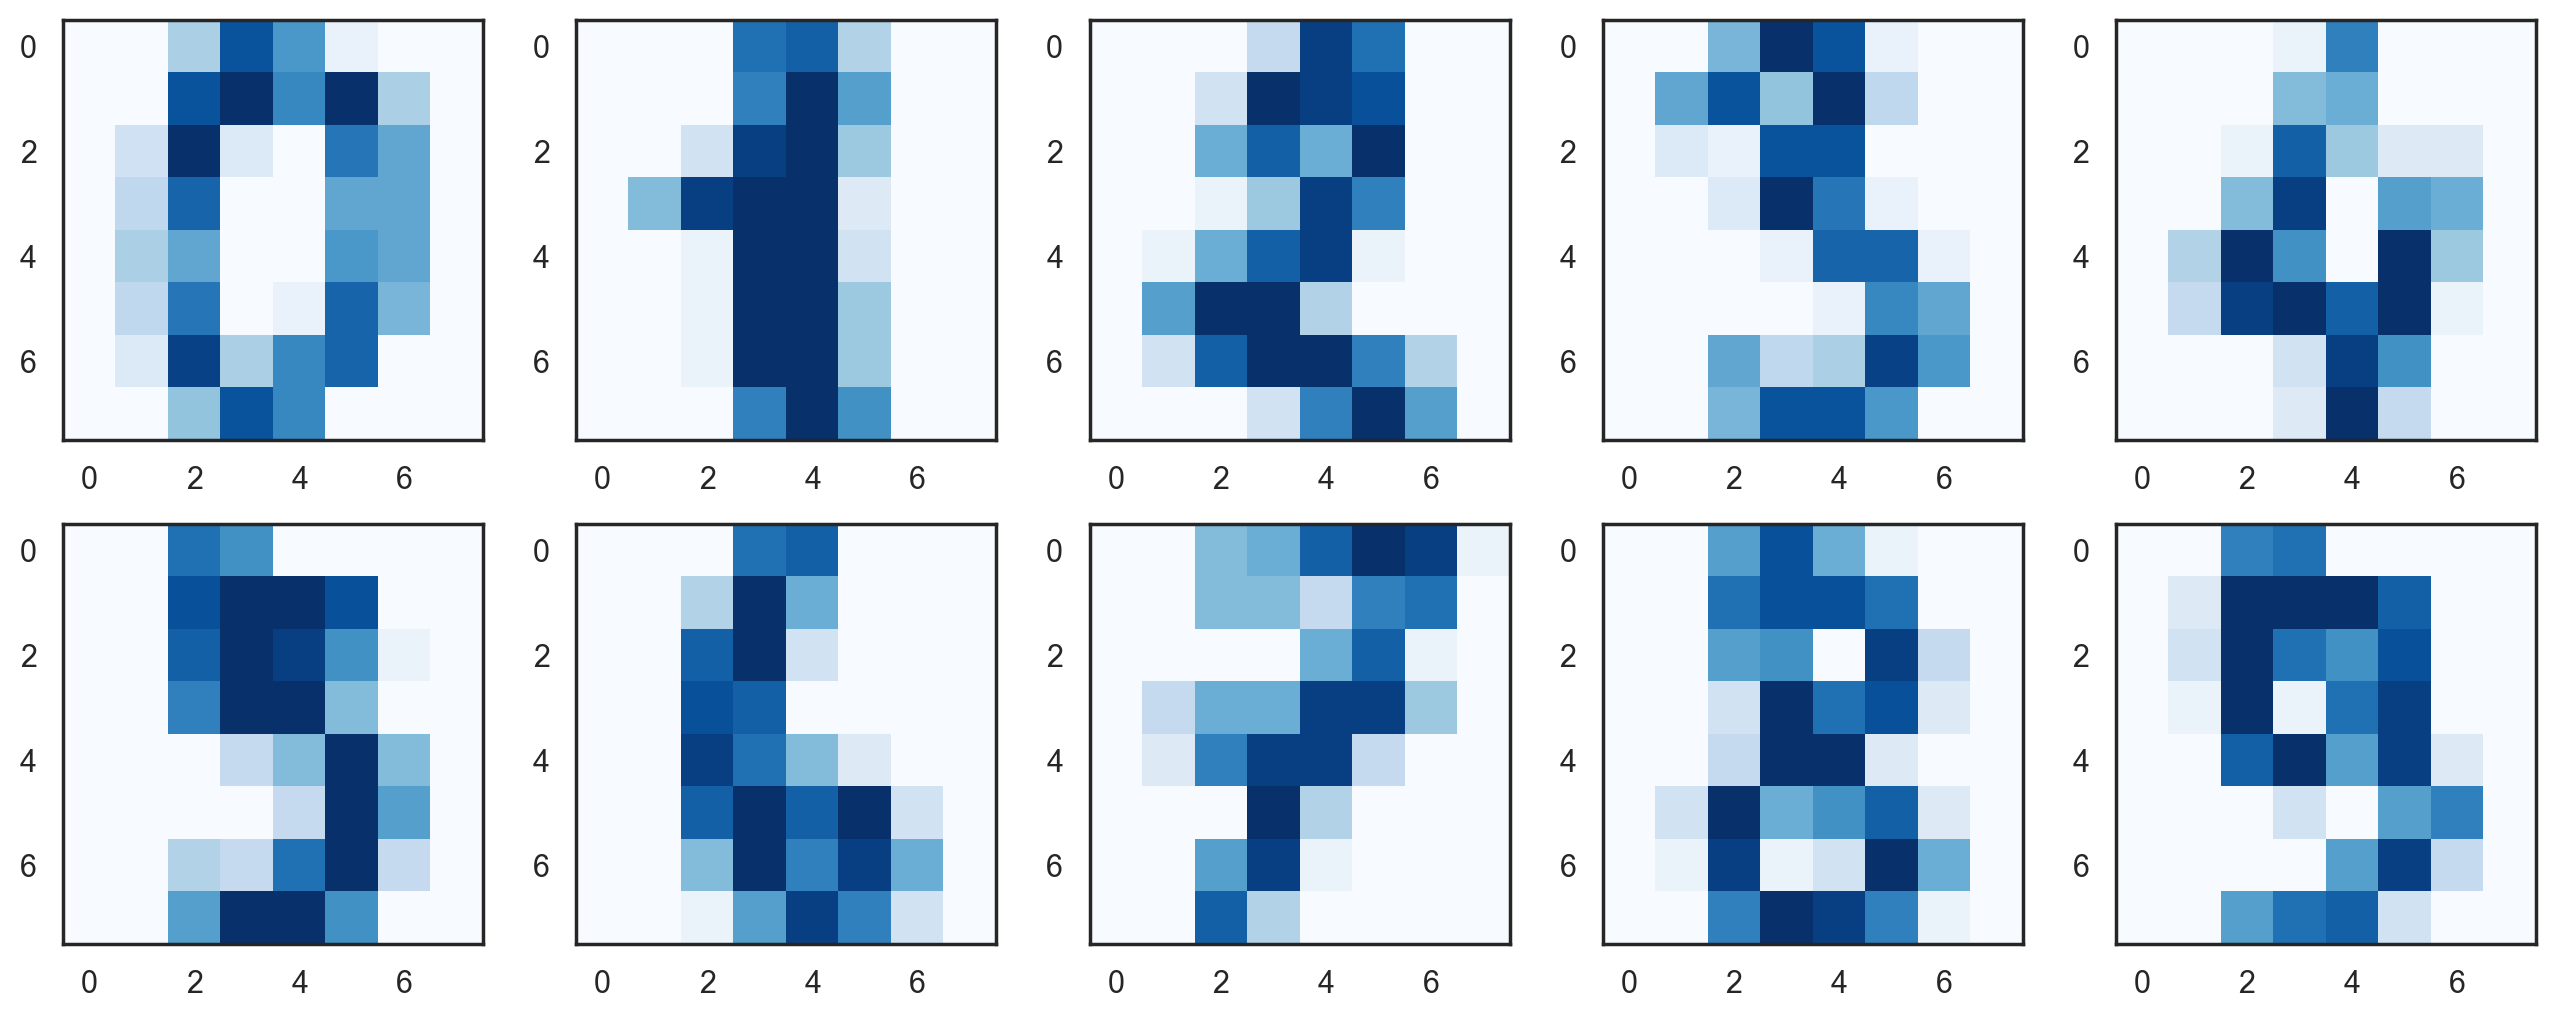

In [9]:
# f, axes = plt.subplots(5, 2, sharey=True, figsize=(16,6))
plt.figure(figsize=(16, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X[i, :].reshape([8,8]), cmap="Blues")

Our data has 64 dimensions, but we are going to reduce it to only 2 and see that, even with just 2 dimensions, we can clearly see that digits separate into clusters.

Projecting 64-dimensional data to 2D


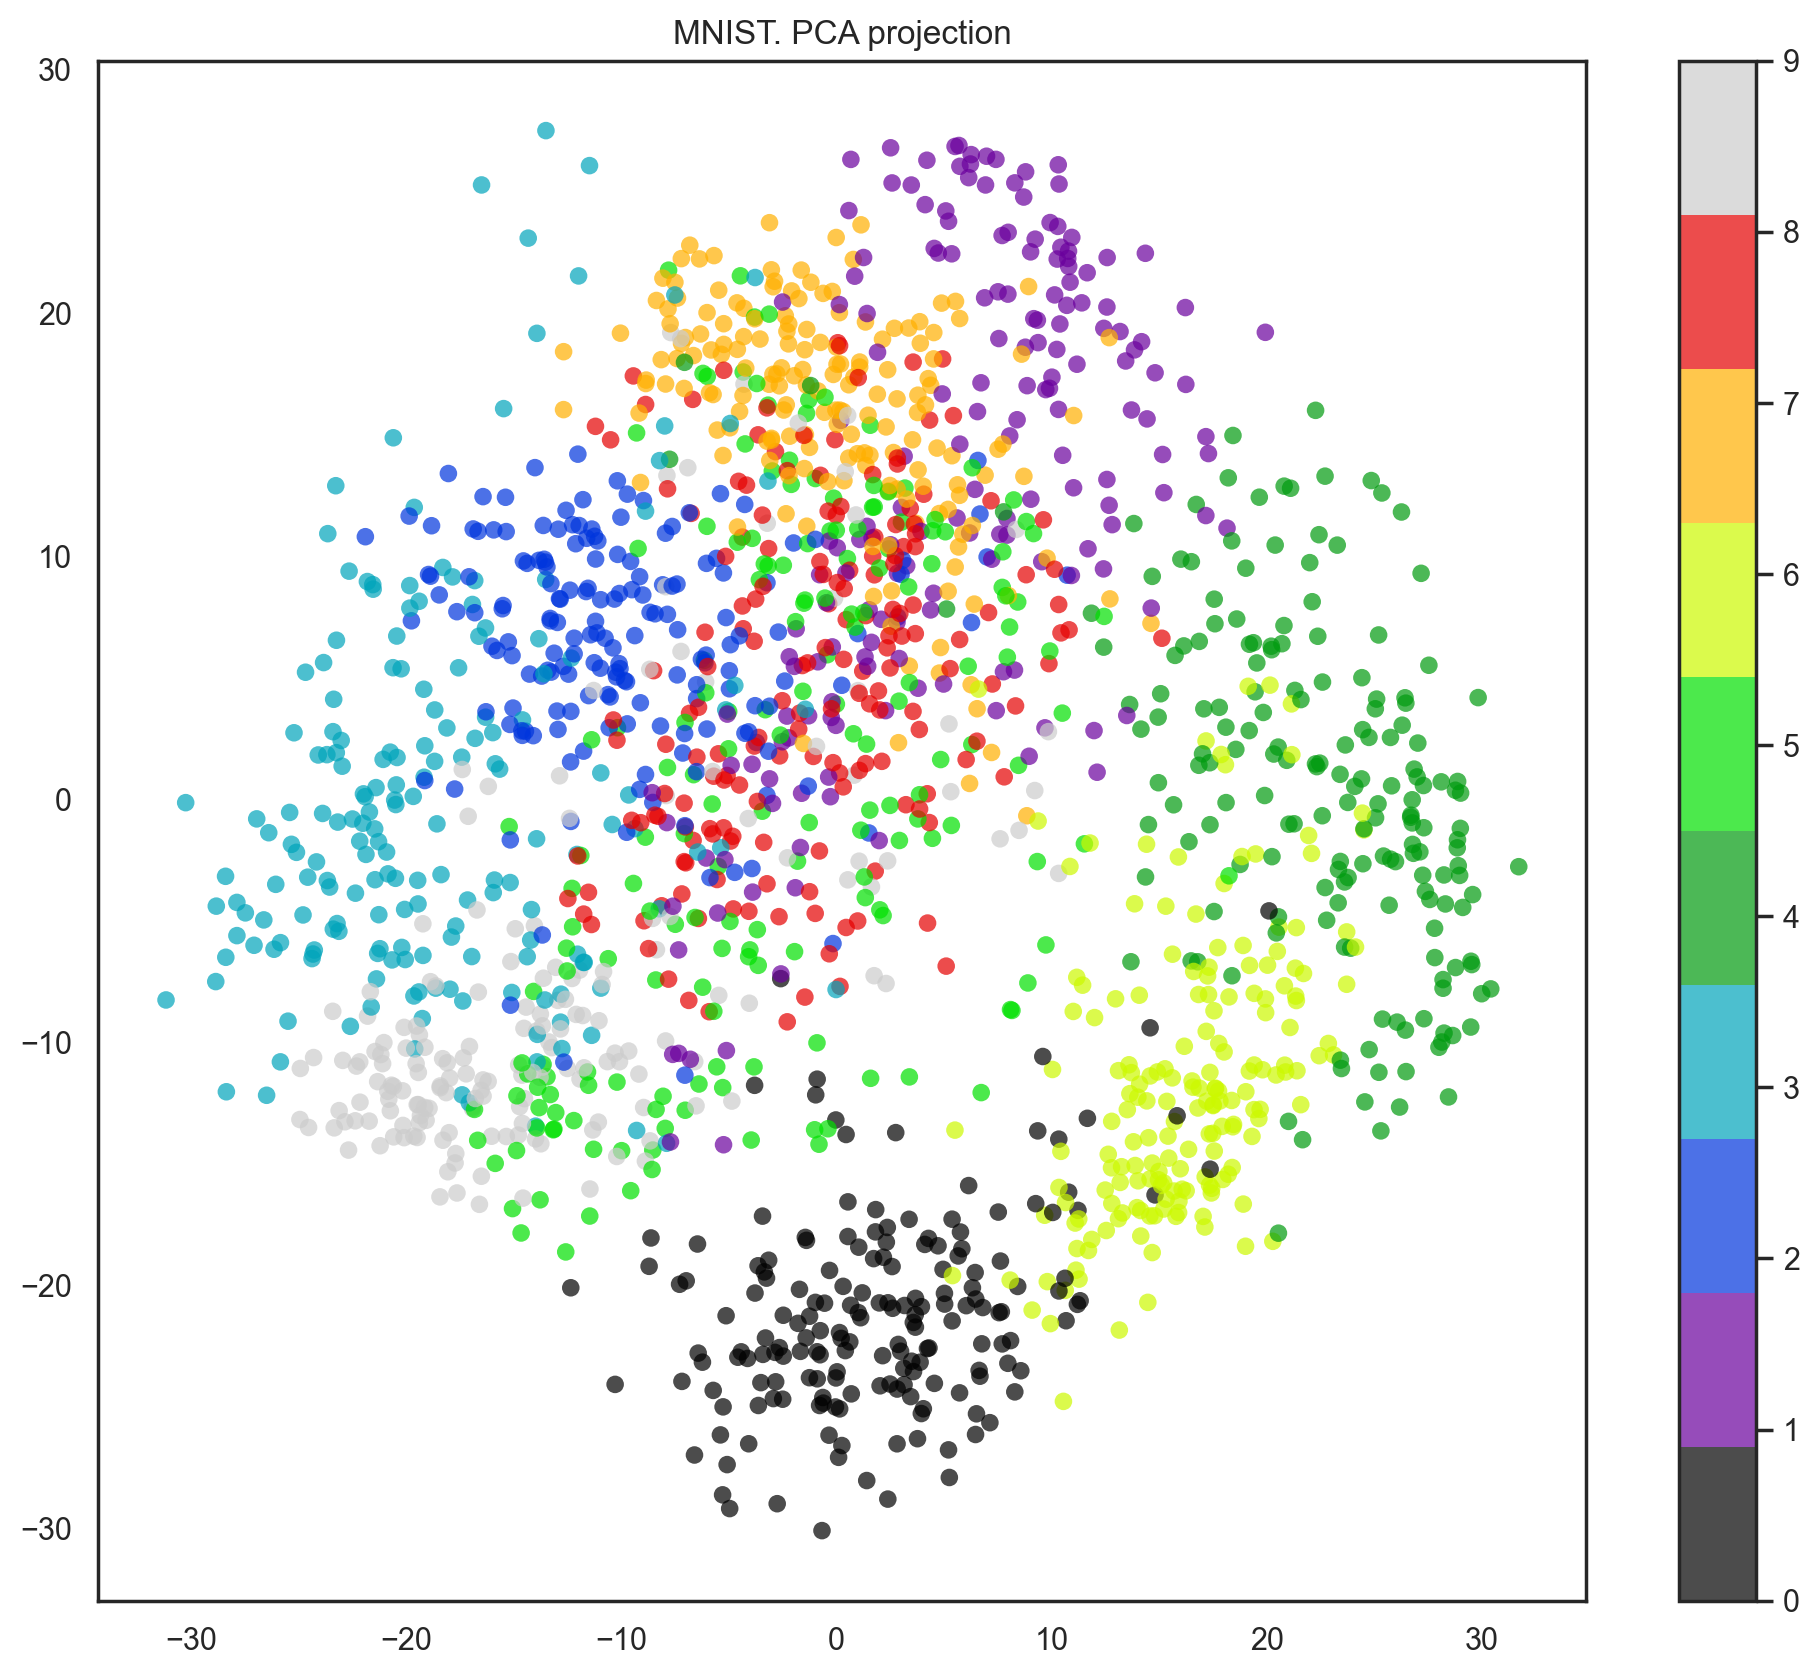

In [10]:
pca = decomposition.PCA(n_components=2)
X_reduced = pca.fit_transform(X)

print("Projecting %d-dimensional data to 2D" % X.shape[1])

plt.figure(figsize=(12,10))
plt.scatter(
    X_reduced[:,0],
    X_reduced[:, 1],
    c= y,
    edgecolors="none",
    alpha=0.7,
    s=40,
    cmap=plt.get_cmap("nipy_spectral", 10)
)
plt.colorbar()
plt.title("MNIST. PCA projection");

This plot is actually a great way to understand what **PCA does and doesn't do**.

### What PCA is doing

PCA is taking the original data (each digit image has 64 features in `load_digits`, since it's an 8×8 image) and reducing it to **2 numbers**:

```text
Original image (64 pixels)
        │
        ▼
PCA
        │
        ▼
(PC1, PC2)
```

Every dot in your plot is one digit image.

* **x-axis** = First Principal Component (PC1)
* **y-axis** = Second Principal Component (PC2)

These axes are **not** pixel values or digit labels. They are new features that PCA learned to capture the largest variation in the dataset.

---

## What the colors tell you

The colors are the true digit labels.

* Black = 0
* Purple = 1
* Blue = 2
* ...
* Gray = 9

PCA **does not know these labels**. It only sees the images.

The fact that similarly colored points tend to group together means:

> Images of the same digit are naturally similar in the original feature space.

---

## What can you conclude from this graph?

### ✅ 1. Some digits are well separated

For example, the black points (digit 0) form a cluster near the bottom.

This means

> PCA found directions where zeros look quite different from other digits.

---

### ✅ 2. Some digits overlap

Look near the center.

You'll see lots of

* red
* orange
* green
* yellow

mixed together.

This means

> Those digits have similar pixel patterns, so PCA cannot completely separate them using only 2 dimensions.

---

### ✅ 3. PCA preserves overall structure

Notice the data forms one large cloud.

PCA tries to preserve

* large-scale distances
* overall variance

It **does not** try to separate classes.

That's why different colors overlap.

---

## Why doesn't PCA perfectly separate the digits?

Because PCA is

* **unsupervised** (doesn't know the labels)
* **linear**

It asks:

> "What directions explain the most variation?"

It does **not** ask:

> "What directions separate 0s from 1s?"

Those are different objectives.

---

## What would a perfect PCA plot look like?

If PCA could perfectly separate digits, you'd see

```text
(0)      (1)

      (2)

(3)      (4)

      (5)

(6)      (7)

(8)      (9)
```

Every color would form its own isolated cluster.

Your plot doesn't look like that because two principal components aren't enough to capture all the complexity of handwritten digits.

---

## Compare this with t-SNE

When you later plot t-SNE, you'll probably see something like

```text
○○○○○          ●●●●●

□□□□□          ▲▲▲▲▲

★★★★★          ♥♥♥♥♥
```

where each color forms a much tighter cluster.

This tells you that **t-SNE is better for visualization**, while PCA is better for:

* reducing dimensionality efficiently,
* removing noise,
* speeding up other algorithms,
* and preserving global structure.

---

### The main takeaway from your PCA plot

From this graph, you should conclude:

* ✔️ PCA reduced the original **64-dimensional** digit data to **2 dimensions**.
* ✔️ Similar digits tend to be placed near each other.
* ✔️ Some digits (like 0) are relatively well separated.
* ✔️ Many digits overlap because **2 linear components are not enough to fully distinguish all handwritten digits**.
* ✔️ PCA captures the directions of **maximum variance**, **not** the directions that best separate digit classes.


----

Indeed, with t-SNE, the picture looks better since PCA has a linear constraint while t-SNE does not. However, even with such a small dataset, the t-SNE algorithm takes significantly more time to complete than PCA.

t-sne :  find a projection for a high-dimensional feature space onto a plane (or a 3D hyperplane, but it is almost always 2D) such that those points that were far apart in the initial n-dimensional space will end up far apart on the plane. Those that were originally close would remain close to each other.

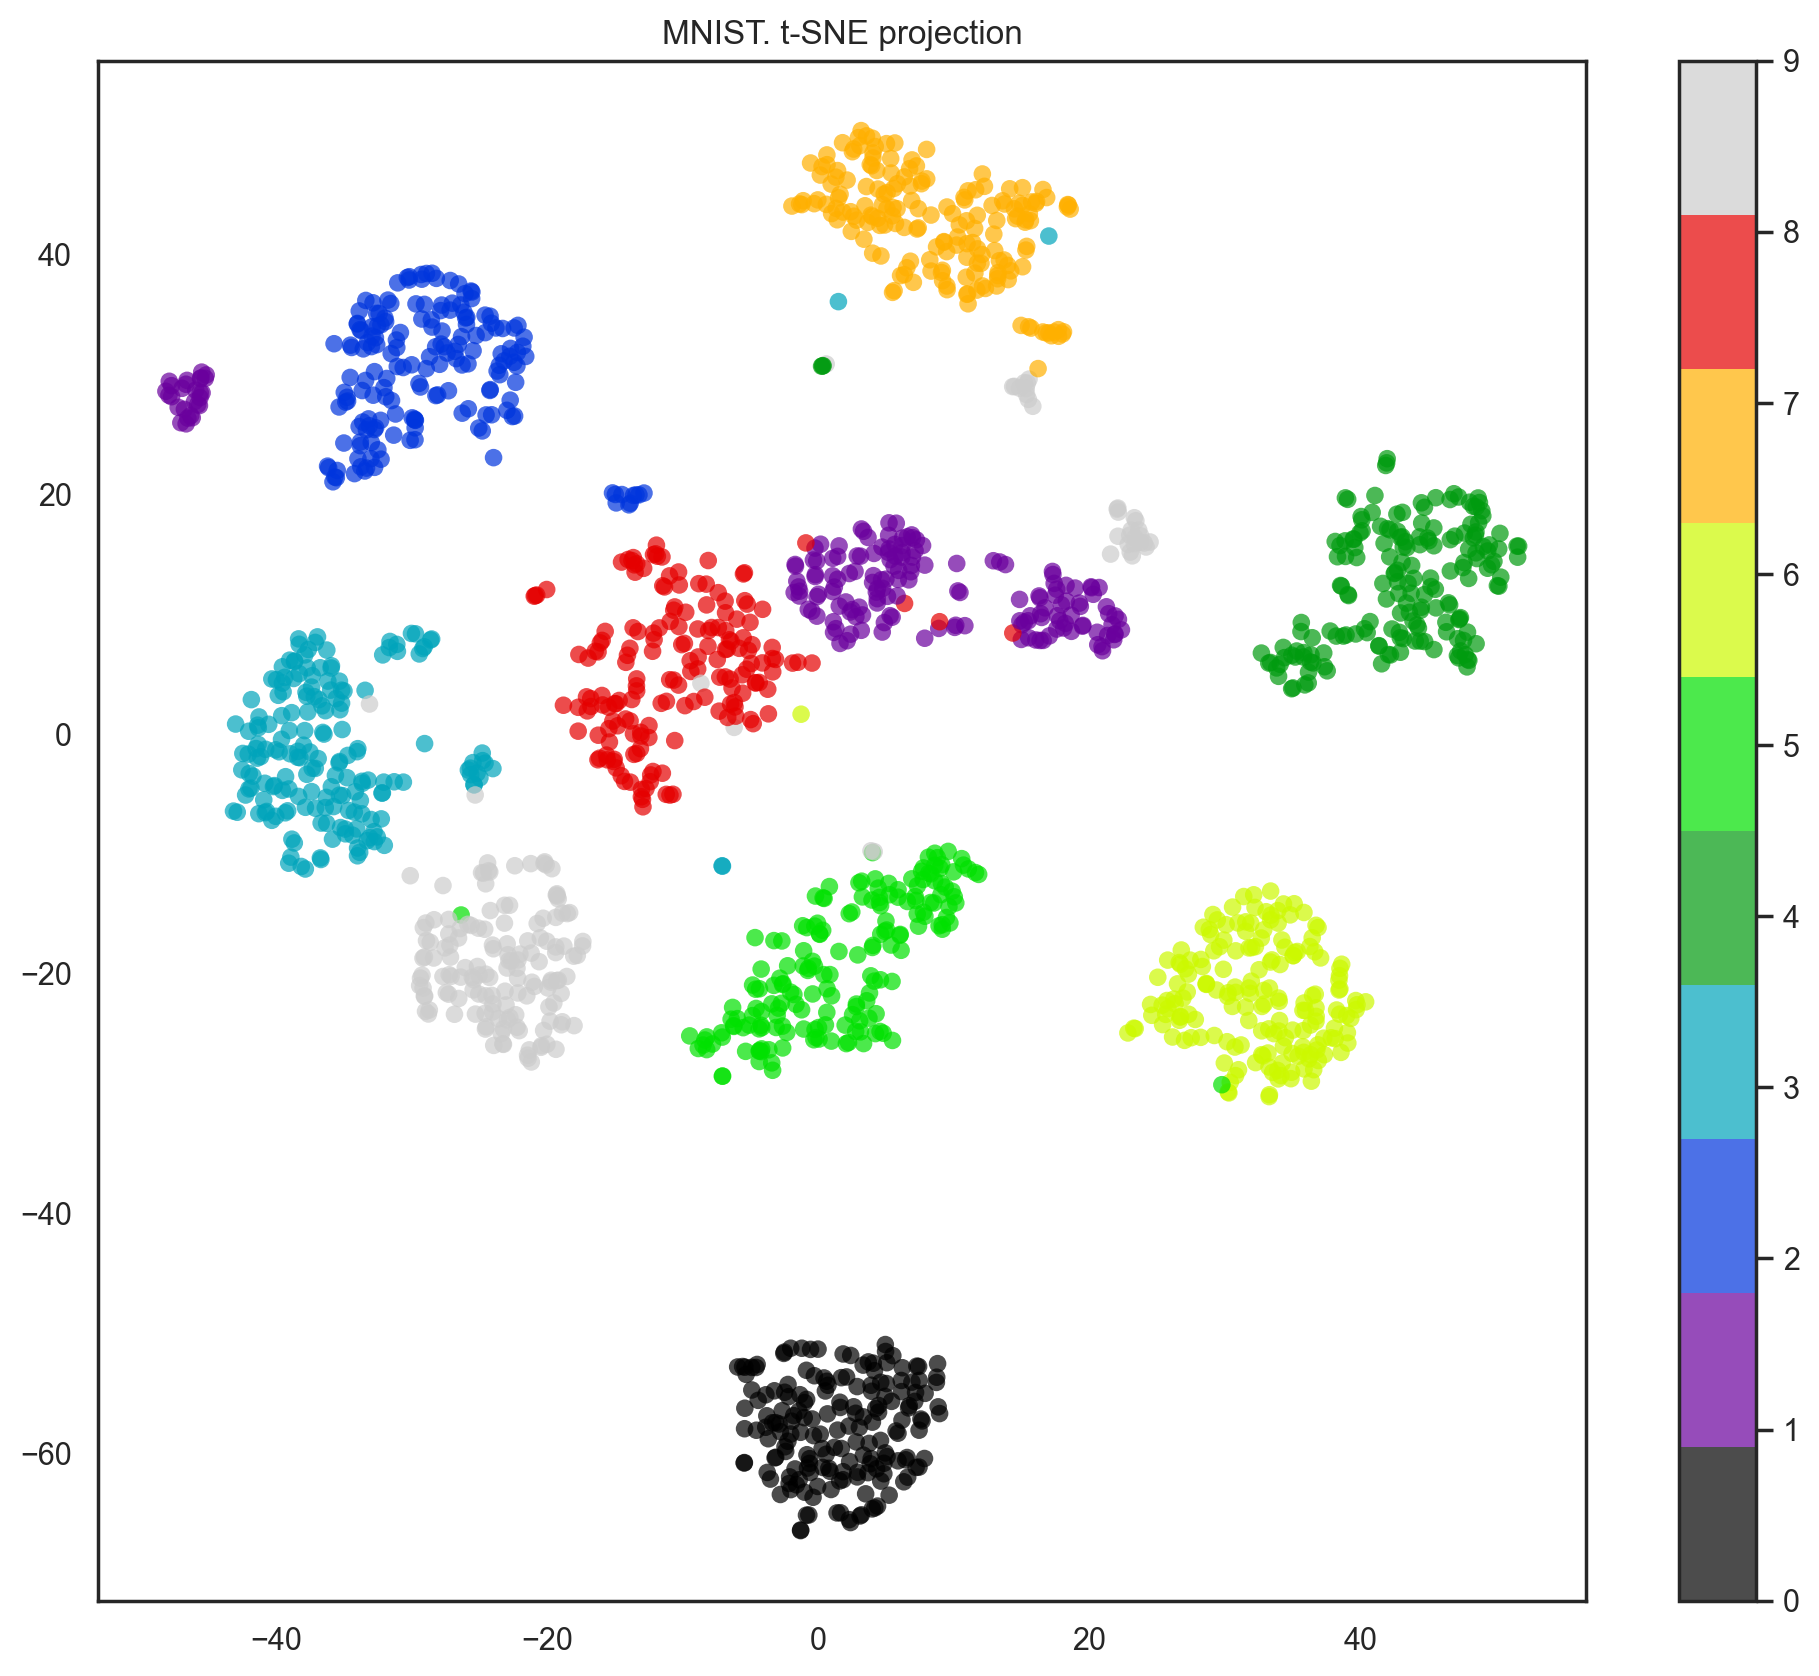

In [11]:
from sklearn.manifold import TSNE

tsne = TSNE(random_state=17)

X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(12, 10))
plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=y,
    edgecolors="none",
    alpha=0.7,
    s=40,
    cmap=plt.get_cmap("nipy_spectral",10)
)
plt.colorbar()
plt.title("MNIST. t-SNE projection");

In practice, we would choose the number of principal components such that we can explain 90% of the initial data variance (via the explained_variance_ratio). Here, that means retaining 21 principal components; therefore, we reduce the dimensionality from 64 features to 21.

``` How do we know 90% of initial data variance is rataining 21 principal components ?  ```

### Step 1: What is variance?

Each of the original 64 features (pixels in the `load_digits` dataset) has some variation across all images.

PCA finds new axes (principal components) such that:

* **PC1** captures the maximum possible variance.
* **PC2** captures the next highest variance, while being perpendicular to PC1.
* **PC3** captures the next highest, and so on.

Suppose after running PCA, you get something like:

| Principal Component | Variance Explained |
| ------------------- | -----------------: |
| PC1                 |                15% |
| PC2                 |                13% |
| PC3                 |                10% |
| PC4                 |                 8% |
| PC5                 |                 7% |
| ...                 |                ... |
| PC64                |              0.01% |

These percentages always sum to **100%**.

---

### Step 2: Cumulative variance

Instead of looking at each component individually, we keep adding them.

| Components | Cumulative Variance |
| ---------- | ------------------: |
| PC1        |                 15% |
| PC1 + PC2  |                 28% |
| PC1–PC3    |                 38% |
| PC1–PC4    |                 46% |
| PC1–PC5    |                 53% |
| ...        |                 ... |
| PC1–PC21   |             **90%** |
| PC1–PC64   |            **100%** |

Notice that after **21 components**, we've already explained **90%** of the variation in the original data.

That means the remaining 43 components together contribute only about **10%** of the total variance.

---

### Step 3: Why can 21 components represent 64 features?

The original data has **64 features**, but many of those features are **correlated**.

For example, in handwritten digits:

* If the top-left pixel is bright, the neighboring pixels are often bright too.
* Strokes occupy groups of adjacent pixels.

So the 64 pixel values don't vary independently.

Imagine measuring a person's:

* Height
* Arm length
* Leg length
* Shoe size

These measurements are correlated. You don't need all of them to describe most of the variation among people.

The same idea applies to digit images.

---

### Step 4: How does scikit-learn know it's 21?

Scikit-learn computes the explained variance ratio:

```python
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X)

print(pca.explained_variance_ratio_)
```

You might get something like:

```python
[0.148, 0.136, 0.117, 0.084, ...]
```

Then compute the cumulative sum:

```python
import numpy as np

np.cumsum(pca.explained_variance_ratio_)
```

Suppose it returns:

```text
[0.148
 0.284
 0.401
 ...
 0.903   <-- 21st component
 ...
 1.000]
```

The first value reaching **0.90** tells you that **21 principal components** are enough.

You can even let scikit-learn choose this automatically:

```python
pca = PCA(n_components=0.90)
X_reduced = pca.fit_transform(X)

print(pca.n_components_)
```

It will print:

```text
21
```

---

### The key intuition

Think of it like summarizing a book:

* The original book has **64 pages** (features).
* The first few chapters contain most of the important story.
* By reading the first **21 pages**, you've understood **90% of the story**.
* The remaining **43 pages** add only minor details.

PCA works similarly: it orders the components by importance. In the `load_digits` dataset, the first **21 principal components** capture about **90% of the information (variance)** in the original 64-dimensional data, so you can reduce from **64 dimensions to 21** while losing only about **10%** of the total variance.


In [12]:
pca = decomposition.PCA(n_components=0.90)
X_reduced = pca.fit_transform(X)

print(pca.n_components_)

21


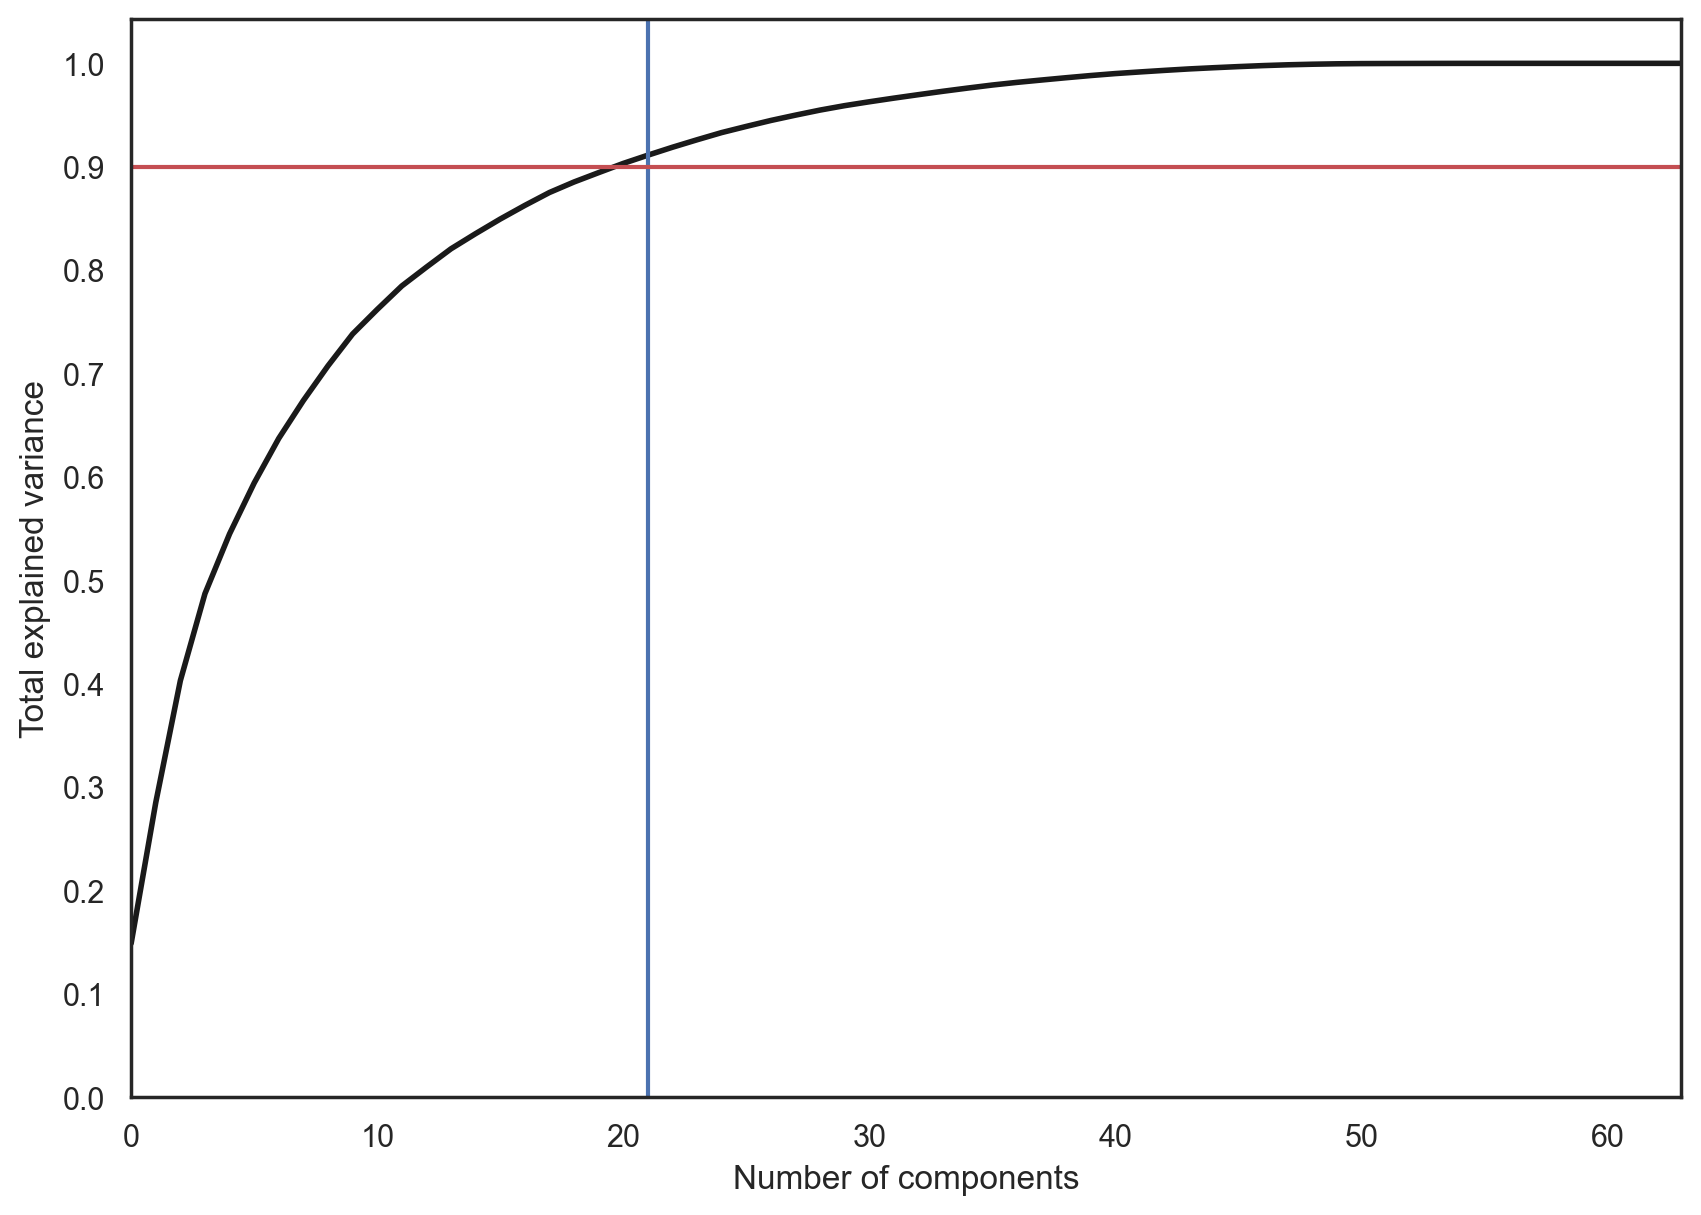

In [13]:
pca = decomposition.PCA().fit(X)

plt.figure(figsize=(10, 7))
plt.plot(np.cumsum(pca.explained_variance_ratio_), color="k", lw=2)
plt.xlabel("Number of components")
plt.ylabel("Total explained variance")
plt.xlim(0, 63)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.axvline(21, c="b")
plt.axhline(0.9, c="r")
plt.show();

## 2. Clustering

The main idea behind clustering is pretty straightforward. Basically, we say to ourselves, “I have these points here, and I can see that they organize into groups. It would be nice to describe these things more concretely, and, when a new point comes in, assign it to the correct group.” This general idea encourages exploration and opens up a variety of algorithms for clustering.

### K-means

K-means algorithm is the most popular and yet simplest of all the clustering algorithms.
 Here is how it works:

- Select the number of clusters k that you think is the optimal number.

- Initialize k points as “centroids” randomly within the space of our data.

- Attribute each observation to its closest centroid.

- Update the centroids to the center of all the attributed set of observations.

- Repeat steps 3 and 4 a fixed number of times or until all of the centroids are stable (i.e. no longer change in step 4).

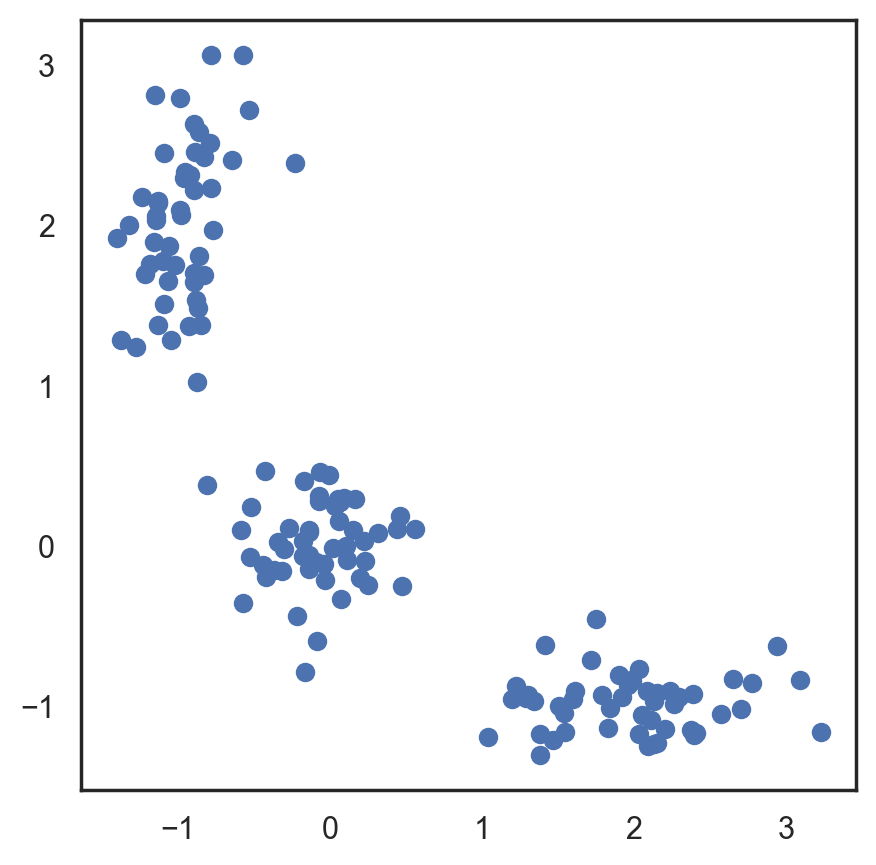

In [14]:
# Let's begin by allocation 3 cluster's points

X = np.zeros((150, 2))

np.random.seed(seed=42)

# mean around 0.0
X[:50, 0] = np.random.normal(loc=0.0, scale=0.3, size=50)
X[:50, 1] = np.random.normal(loc=0.0, scale=0.3, size=50)

# mean around 2.0 and -1.0
X[50:100, 0] = np.random.normal(loc=2.0, scale=0.5, size=50)
X[50:100, 1] = np.random.normal(loc=-1.0, scale=0.2, size=50)

# mean around -1.0 and 2.0
X[100:150, 0] = np.random.normal(loc=-1.0, scale=0.2, size=50)
X[100:150, 1] = np.random.normal(loc=2.0, scale=0.5, size=50)

plt.figure(figsize=(5,5))
plt.plot(X[:,0], X[:,1], "bo")

In [15]:
# Scipy has function that takes 2 tuples and return
# calculated distance between them

from scipy.spatial.distance import cdist

# randomly allocate the 3 centroids
np.random.seed(seed=42)
centroids = np.random.normal(loc=0.0, scale=1.0, size=6)
centroids = centroids.reshape((3,2))

cent_history = []
cent_history.append(centroids)

for i in range(3):
    # calculate the distance from a point to centroid
    distances = cdist(X, centroids)
    # checking whats the closest centroid for the point
    labels = distances.argmin(axis=1)

    # labeling the point according to points distance
    centroids = centroids.copy()
    centroids[0,:] = np.mean(X[labels == 0, :], axis=0)
    centroids[1, :] = np.mean(X[labels == 1, :], axis=0)
    centroids[2, :] = np.mean(X[labels == 2, :], axis=0)

    cent_history.append(centroids)

(150,)
(150,)
(150,)
(150,)


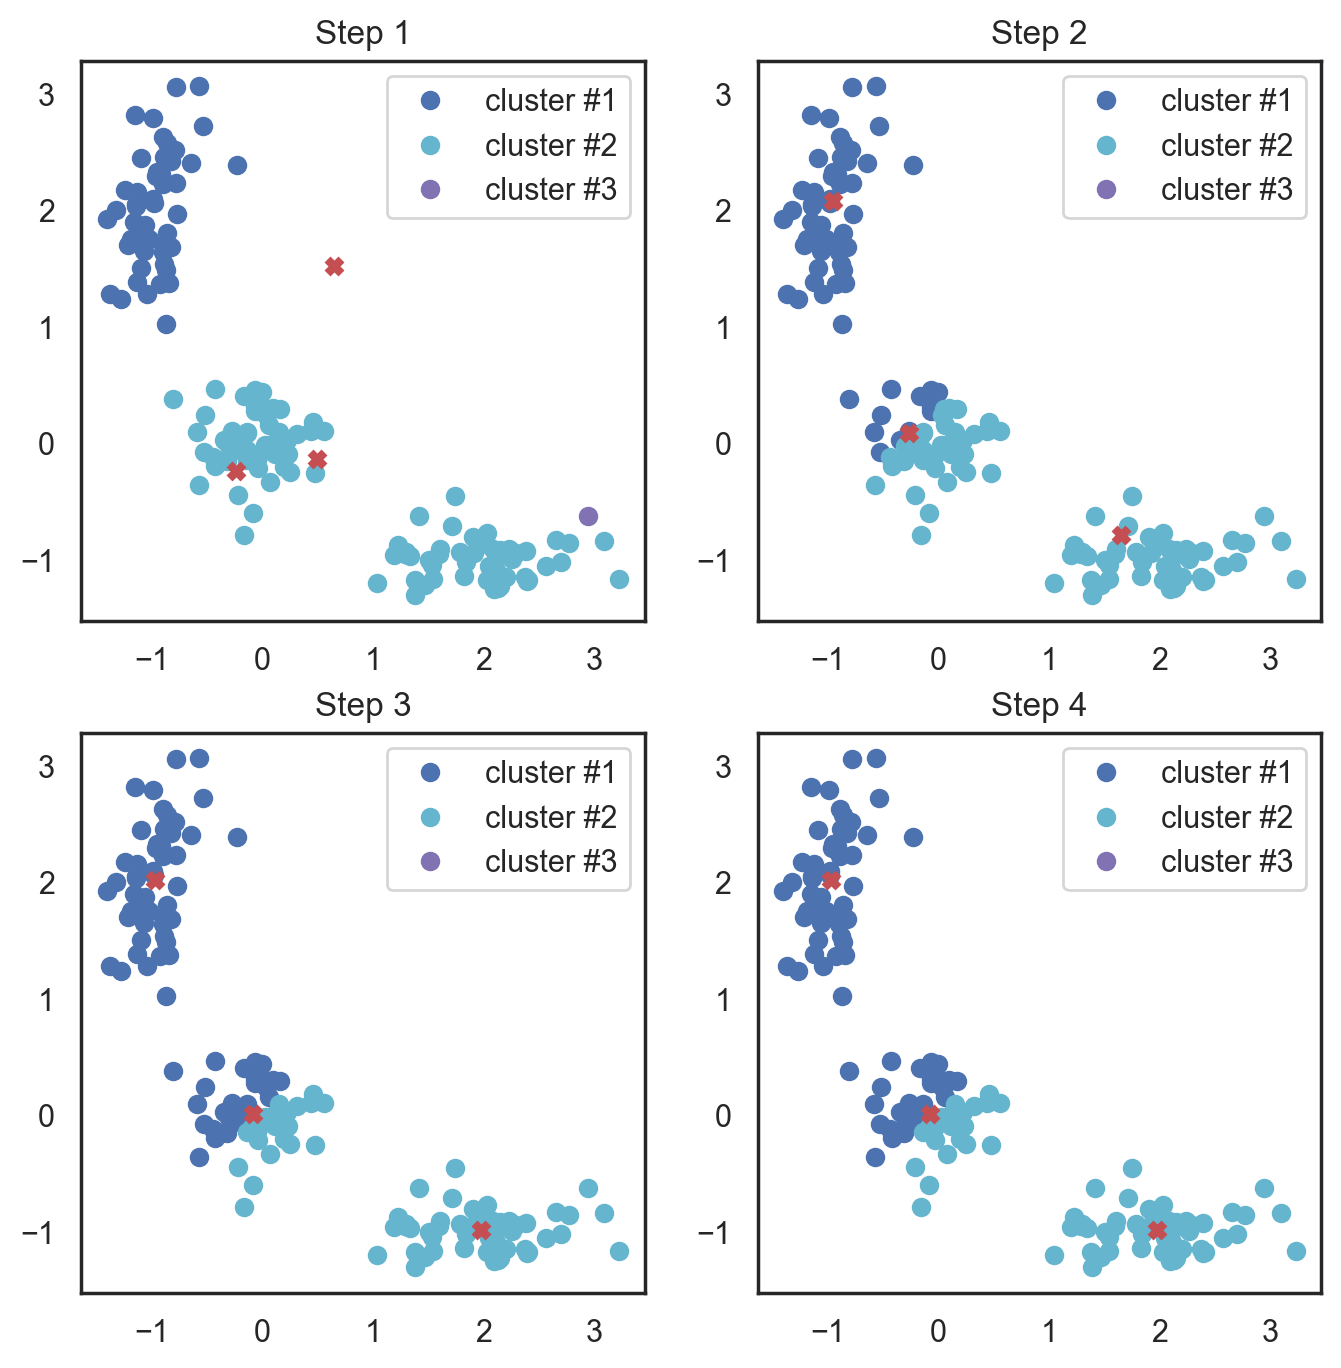

In [16]:
# Let's plot K-means
plt.figure(figsize=(8, 8))

for i in range(4):
    distances = cdist(X, cent_history[i])
    labels = distances.argmax(axis=1)
    print(labels.shape)

    plt.subplot(2, 2, i + 1)
    plt.plot(X[labels == 0, 0], X[labels == 0, 1], "bo", label="cluster #1")
    plt.plot(X[labels == 1, 0], X[labels == 1, 1], "co", label="cluster #2")
    plt.plot(X[labels == 2, 0], X[labels == 2, 1], "mo", label="cluster #3")
    plt.plot(cent_history[i][:, 0], cent_history[i][:, 1], "rX")
    plt.legend(loc=0)
    plt.title("Step {:}".format(i + 1))

## Choosing the number of clusters for K-means

when working with k-means, we optimize the sum of squared distances between the observations and their centroids.
This definition seems reasonable – we want our observations to be as close to their centroids as possible. But, there is a problem – the optimum is reached when the number of centroids is equal to the number of observations, so you would end up with every single observation as its own separate cluster.

In [17]:
from sklearn.cluster import KMeans

In [18]:
inertia = []
for k in range(1,8):
    kmeans = KMeans(n_clusters=k, random_state=1, n_init="auto").fit(X)
    inertia.append(kmeans.inertia_)

Text(0, 0.5, '$J(C_k)$')

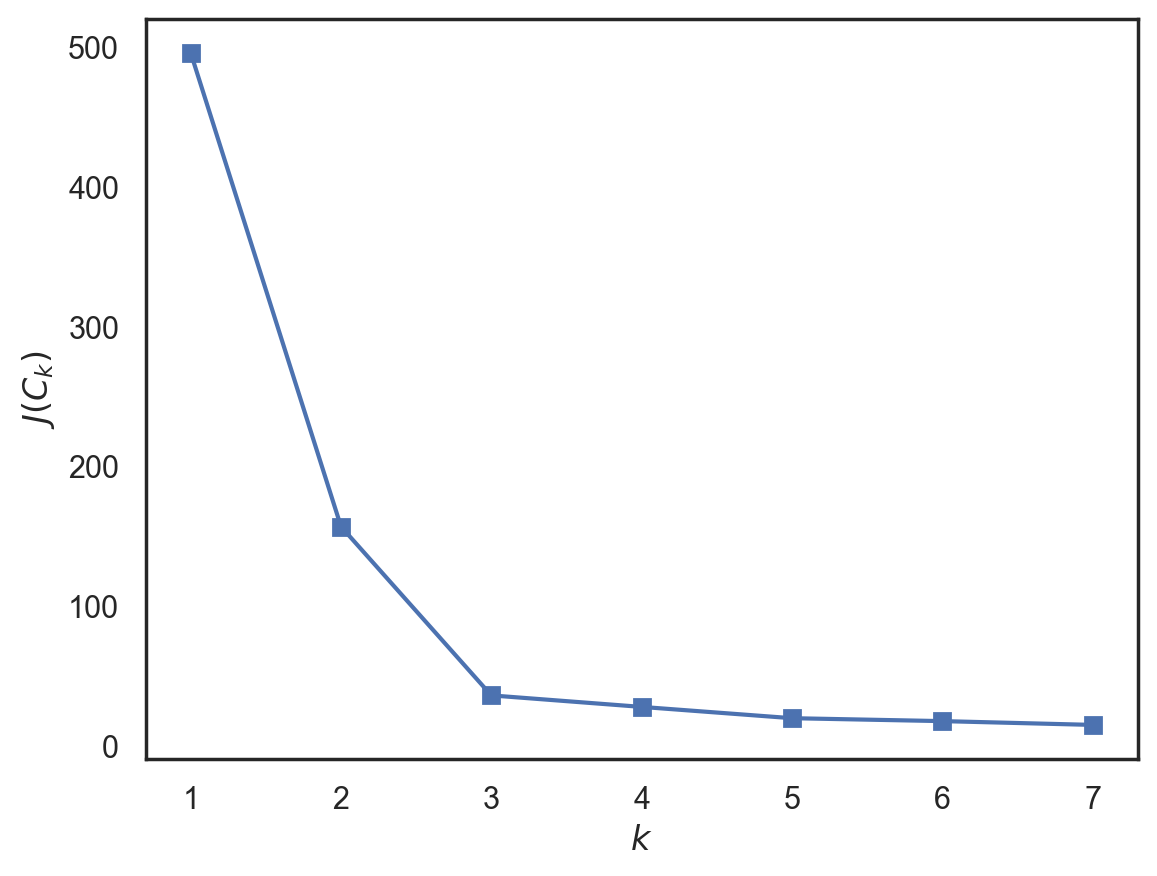

In [19]:
plt.plot(range(1, 8), inertia, marker="s")
plt.xlabel("$k$")
plt.ylabel("$J(C_k)$")

We see that $$ J(C_k) $$ decreases significantly until the number of clusters is 3 and then does not change as much anymore. This means that the optimal number of clusters is 3.

## Issues

### What does NP-hard mean?

An **NP-hard** problem is a problem for which **no efficient algorithm is known** that always finds the optimal solution as the input size grows.

In other words:

* ✅ Small inputs → easy to solve.
* ❌ Large inputs → the number of possibilities becomes enormous, making it impractical to check them all.

It does **not** mean the problem is impossible—just that finding the **best** solution is computationally very difficult.

---

### Simple Example 1: Choosing the Best Route

Suppose you need to visit 5 cities exactly once and return home.

You could try every possible route and pick the shortest one.

For 5 cities:

* There are only 120 possible routes.

For 20 cities:

* There are about **2.4 × 10¹⁸** possible routes!

Checking every route would take far too long.

This is an NP-hard problem (the Traveling Salesman Problem).

---

### Simple Example 2: K-means

Suppose you have **4 observations** and want **2 clusters**.

```
A  B  C  D
```

Possible cluster assignments include:

```
{A,B} {C,D}
{A,C} {B,D}
{A,D} {B,C}
...
```

To find the **absolute best clustering**, you'd have to examine **all possible ways** of assigning points to clusters.

With:

* 4 points → only a few possibilities.
* 1000 points → an astronomical number of possibilities.

That's why finding the exact optimum for K-means is NP-hard.

---

### So why is K-means fast in practice?

The K-means algorithm you learn is **not** trying every possible clustering.

Instead, it uses a clever iterative approach:

1. Guess initial centroids.
2. Assign each point to the nearest centroid.
3. Recompute centroids.
4. Repeat until things stop changing.

This usually finds a **good** solution quickly, but **not necessarily the best possible one**.

---

### What the sentence means

> "K-means is NP-hard. For (d) dimensions, (k) clusters, and (n) observations, we will find a solution in (O(n^{dk+1})) time."

This refers to the **exact** K-means optimization problem.

* The exact solution requires checking an enormous number of clusterings, and its worst-case running time grows roughly like (O(n^{dk+1})), which becomes infeasible for large datasets.
* The **standard Lloyd's K-means algorithm** avoids this exhaustive search and is much faster, but it only guarantees a **locally optimal** solution, not the global optimum.

**A simple analogy:**

* **Exact K-means (NP-hard):** Like trying every possible seating arrangement for 100 guests to find the absolute best one.
* **Lloyd's K-means algorithm:** Like starting with a reasonable seating plan and making local swaps until no obvious improvement remains. It finishes quickly and usually produces a good arrangement, even if it's not the absolute best.


## Affinity Propagation

## The main idea

Instead of saying:

> "I want exactly 3 clusters."

Affinity Propagation says:

> "Let the data decide which observations should become cluster centers."

The cluster centers are called **exemplars** (or "role models").

Every observation asks:

> **"Which other observation is the best representative of me?"**

---

## Simple Example

Suppose we have five students based on their marks.

|Observation|Marks|
|---|---|
|A|20|
|B|22|
|C|21|
|D|85|
|E|87|

Clearly,

- A, B, C are similar.
    
- D, E are similar.
    

We would expect

- B (or C) to become the representative for A, B, C.
    
- D (or E) to become the representative for D, E.
    

Affinity Propagation figures this out automatically.

---

# Step 1: Similarity

The similarity function is

[  
s(x_i,x_j)=-|x_i-x_j|^2  
]

Notice the minus sign.

If two observations are close,

distance is small,

so similarity is close to **0**.

Example

Between A=20 and B=22

distance

[  
=2  
]

Similarity

[  
-(2^2)=-4  
]

Between A=20 and D=85

distance

[  
=65  
]

Similarity

[  
-(65^2)=-4225  
]

So

- A and B have similarity **−4**
    
- A and D have similarity **−4225**
    

Since

[  
-4>-4225  
]

A is much more similar to B.

---

# Step 2: Responsibility matrix (r)

This answers the question

> **"How strongly should point i choose point k as its representative?"**

Imagine A is choosing.

Possible representatives:

- B
    
- C
    
- D
    
- E
    

Suppose similarities are

|Candidate|Similarity|
|---|---|
|B|-4|
|C|-1|
|D|-4225|
|E|-4489|

C is the closest.

So A says

> "C is much better than everyone else."

Therefore

[  
r(A,C)  
]

becomes large.

For B,

[  
r(A,B)  
]

becomes smaller.

For D,

it becomes very negative.

So responsibility is basically

> **"How much do I like this candidate compared with all the others?"**

---

# Step 3: Availability matrix (a)

Now the candidate also has an opinion.

Suppose lots of observations say

> "We want C."

Then C becomes a popular representative.

Availability answers

> **"Is C willing to represent me?"**

If many observations support C,

availability becomes high.

If nobody supports C,

availability stays low.

So

Responsibility is

> "I want C."

Availability is

> "C is a good representative."

---

# Together

A point becomes an exemplar only when

- many observations want it
    
- and it is a good representative.
    

---

# Small Analogy

Imagine a class choosing a class leader.

Each student votes.

Responsibility:

Student A says

> "I think Bob should be leader."

Availability:

Everyone else also thinks Bob should be leader.

So Bob becomes leader.

But suppose only one student votes for Charlie.

Then Charlie won't become leader.

Affinity Propagation repeats this process until everyone agrees on who the leaders (cluster centers) are.

---

# What do the equations mean?

### Responsibility

# [ 
r_{i,k}

## s(i,k)

\max_{k'\neq k}  
(a_{i,k'}+s(i,k'))  
]

Translation:

> "How much better is candidate **k** than my next-best candidate?"

If C is much better than everyone else,

responsibility becomes large.

---

### Availability

# [  
a_{i,k}

\min  
\left(  
0,;  
r_{k,k}  
+  
\sum  
\max(0,r_{i',k})  
\right)  
]

Translation:

> "How much support does candidate **k** receive from everyone else?"

If lots of observations want C,

availability becomes positive (or less negative).

---

## Final intuition

Think of Affinity Propagation as a **voting process**:

- **Similarity** → "Who is most like me?"
    
- **Responsibility** → "I vote for this point to represent me."
    
- **Availability** → "This point has enough support to represent others."
    

The algorithm keeps passing these "votes" (called **messages**) back and forth until a stable set of representatives (exemplars) emerges. Those exemplars become the cluster centers automatically, so unlike K-means, you **don't need to specify the number of clusters in advance**.

## Spectral clustering

This is actually much easier to understand than the terminology suggests. The core idea of **Spectral Clustering** is:

> **Instead of clustering the points directly, cluster the relationships (graph) between the points.**

Let's go through it step by step.

---

# Step 1: Imagine your data points

Suppose we have six points.

```
A      B      C


          D      E      F
```

Visually, there seem to be two groups.

---

# Step 2: Build a graph

Instead of thinking of these as points, imagine every point is a **person**.

Now connect every pair of people with a rope.

```
A -------- B
|\        /|
| \      / |
|  \    /  |
|   \  /   |
|    \/    |
C -------- D
 \        /
  \      /
   \    /
    E--F
```

Every rope has a **strength**.

Strong rope
→ very similar points

Weak rope
→ very different points

This graph is represented by the **adjacency matrix**.

---

# Step 3: Create the adjacency matrix

Suppose

```
A and B are close

B and C are close

A and C are close

D,E,F are close

A and E are far
```

Then

|   | A   | B   | C   | D   | E   | F   |
| - | --- | --- | --- | --- | --- | --- |
| A | 0   | -1  | -2  | -20 | -25 | -24 |
| B | -1  | 0   | -1  | -18 | -22 | -21 |
| C | -2  | -1  | 0   | -17 | -20 | -22 |
| D | -20 | -18 | -17 | 0   | -1  | -2  |
| E | -25 | -22 | -20 | -1  | 0   | -1  |
| F | -24 | -21 | -22 | -2  | -1  | 0   |

Recall

Similarity

[
A_{ij}=-||x_i-x_j||^2
]

means

Small distance

↓

Large similarity (less negative)

Large distance

↓

Very negative similarity.

---

# Why make this matrix?

Because now we've converted our dataset into a **graph**.

Instead of saying

```
These are coordinates.
```

we now say

```
These are connected nodes.
```

---

# Step 4: Cut the graph

Suppose the graph looks like

```
A ----- B ----- C

      weak

D ----- E ----- F
```

Imagine the connection between C and D is very weak.

```
A ==== B ==== C -- D ==== E ==== F
```

The algorithm asks

> "Where should I cut the ropes?"

Obviously,

cutting here

```
A ==== B ==== C | D ==== E ==== F
```

creates two groups whose members are strongly connected internally.

---

# Bad cut

Suppose you cut here

```
A ==== B | C ==== D ==== E ==== F
```

Now

A and B become separated from C,

even though

A, B, C were all strongly connected.

That is a bad clustering.

---

# So what does Spectral Clustering want?

It wants

* **strong connections inside each cluster**
* **weak connections between clusters**

Exactly like separating friend groups.

---

# What is the "Normalized Cut"?

Suppose we have

```
A ----- B ----- C

D ----- E ----- F
```

Only one weak connection exists.

```
C ----- D
```

Weight = 1

Everything else has

Weight = 100

Cutting

```
A B C | D E F
```

only removes one weak connection.

Very good.

---

Now suppose we cut

```
A | B C D E F
```

We break

```
A-B

A-C
```

which are both very strong.

Bad.

---

So the algorithm searches for the cut that removes the **least important connections**.

---

# Why is it called Spectral Clustering?

Here's the only "magic" part.

Instead of directly searching all possible cuts (which would be computationally expensive), Spectral Clustering:

1. Builds the adjacency matrix.
2. Computes a matrix called the **graph Laplacian** from it.
3. Finds the **eigenvectors** (the "spectrum") of the Laplacian.
4. Uses those eigenvectors to embed the data into a new space where the clusters become easier to separate.
5. Runs a simple clustering algorithm (often K-Means) on this transformed representation.

The word **spectral** comes from the spectrum (eigenvalues and eigenvectors) of the Laplacian matrix.

---

# Why does this help?

Imagine your data looks like two moons.

```
🌙      🌙
```

K-Means tries to split them with straight lines.

```
🌙 | 🌙
```

which often fails.

Spectral Clustering transforms the data so that these curved shapes become much easier to separate, and then K-Means works well in that new space.

---

# Real-life analogy

Imagine Facebook users.

```
Alice
Bob
Charlie

David
Emma
Frank
```

Friendships are:

```
Alice ↔ Bob
Bob ↔ Charlie

David ↔ Emma
Emma ↔ Frank
```

Very few friendships exist between the two groups.

Instead of using people's ages or locations, Spectral Clustering only looks at the **friendship graph**.

It naturally finds

```
Group 1

Alice
Bob
Charlie

Group 2

David
Emma
Frank
```

because there are many connections within each group and very few between them.

---

# Summary

1. **Build the similarity matrix (adjacency matrix):** every pair of points gets a similarity score.
2. **Treat the data as a graph:** points become nodes, similarities become weighted edges.
3. **Find the best place to "cut" the graph:** keep strong connections inside clusters and cut weak connections between clusters.
4. **Use eigenvectors of the graph Laplacian:** these reveal the graph's natural structure.
5. **Cluster in the transformed space (usually with K-Means):** this produces the final clusters.

The key advantage of Spectral Clustering is that it can discover **complex, non-convex cluster shapes** (like circles, spirals, or two interlocking moons) that algorithms such as K-Means often cannot separate correctly.


## Agglomerative clustering

The algorithm is fairly simple:

- We start by assigning each observation to its own cluster

- Then sort the pairwise distances between the centers of clusters in descending order

- Take the nearest two neighbor clusters and merge them together, and recompute the centers

- Repeat steps 2 and 3 until all the data is merged into one cluster



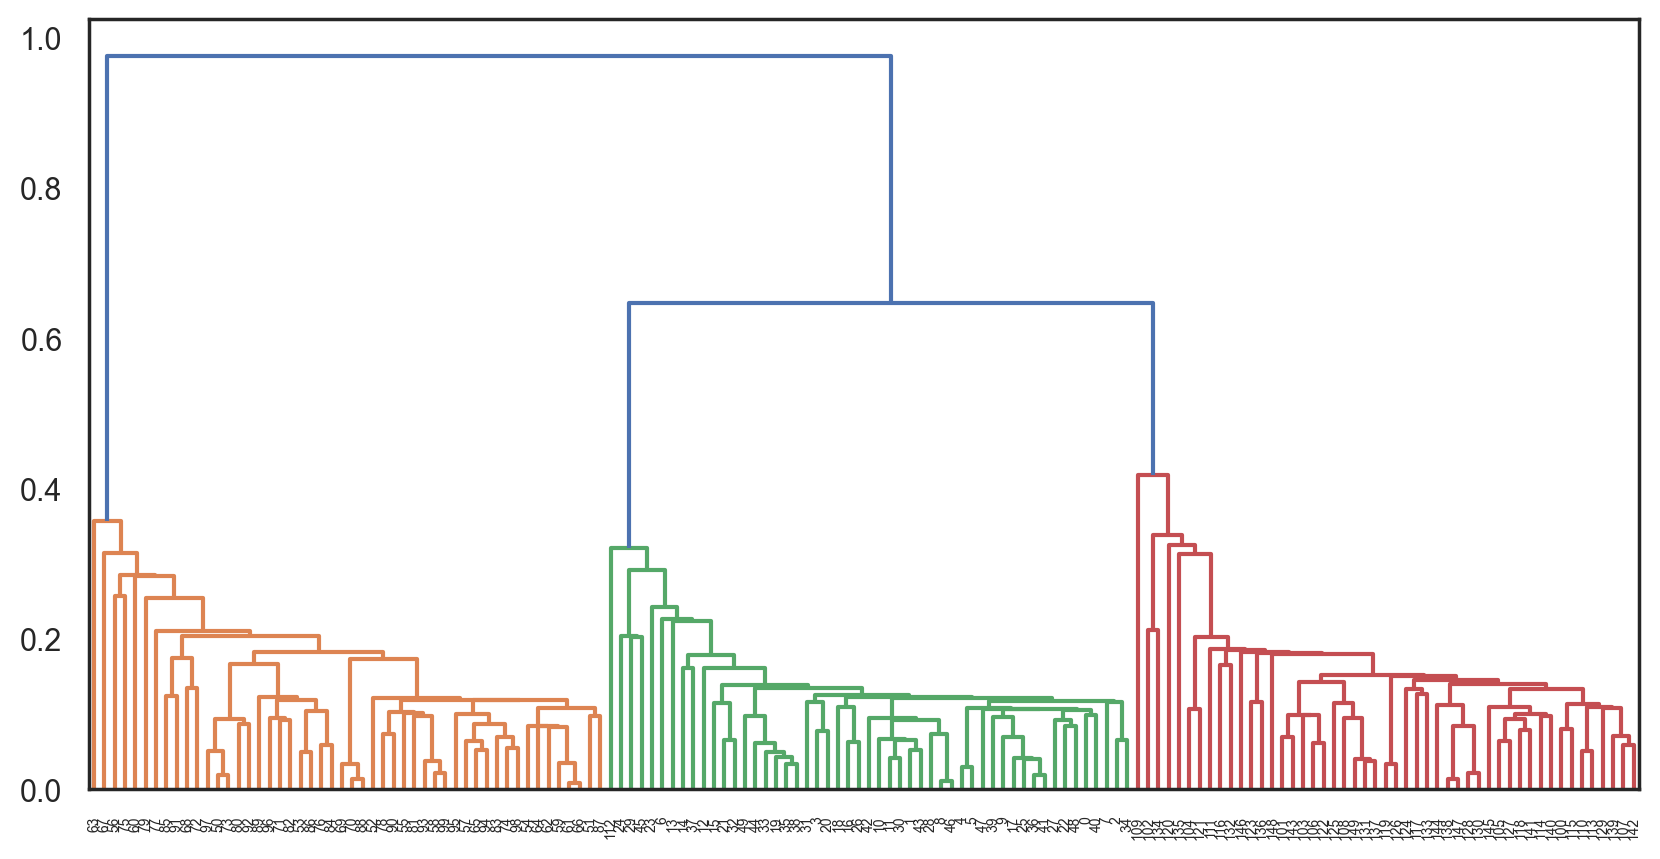

In [20]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist

X = np.zeros((150, 2))

np.random.seed(seed=42)
X[:50, 0] = np.random.normal(loc=0.0, scale=0.3, size=50)
X[:50, 1] = np.random.normal(loc=0.0, scale=0.3, size=50)

X[50:100, 0] = np.random.normal(loc=2.0, scale=0.5, size=50)
X[50:100, 1] = np.random.normal(loc=-1.0, scale=0.2, size=50)

X[100:150, 0] = np.random.normal(loc=-1.0, scale=0.2, size=50)
X[100:150, 1] = np.random.normal(loc=2.0, scale=0.5, size=50)

# pdist will calculate the upper triangle of the pairwise distance matrix
distance_mat = pdist(X)

# linkage — is an implementation of agglomerative algorithm
Z = hierarchy.linkage(distance_mat, "single")
plt.figure(figsize=(10, 5))
dn = hierarchy.dendrogram(Z, color_threshold=0.5)

## Accuracy metrics

In [21]:
import pandas as pd
from sklearn import datasets, metrics
from sklearn.cluster import (AffinityPropagation, AgglomerativeClustering, KMeans, SpectralClustering)

data = datasets.load_digits()
X, y = data.data, data.target

algorithms = []

algorithms.append(KMeans(n_clusters=10, random_state=1, n_init="auto"))
algorithms.append(AffinityPropagation())
algorithms.append(
    SpectralClustering(n_clusters=10, random_state=1, affinity="nearest_neighbors")
)
algorithms.append(AgglomerativeClustering(n_clusters=10))

data = []

for algo in algorithms:
    algo.fit(X)
    data.append(
        (
            {
                "ARI": metrics.adjusted_rand_score(y, algo.labels_),
                "AMI": metrics.adjusted_mutual_info_score(y, algo.labels_),
                "Homogeneity": metrics.homogeneity_score(y, algo.labels_),
                "Completeness": metrics.completeness_score(y, algo.labels_),
                "V-measure": metrics.v_measure_score(y, algo.labels_),
                "Silhouette": metrics.silhouette_score(X, algo.labels_),
            }
        )
    )

results = pd.DataFrame(
    data=data,
    columns=["ARI", "AMI", "Homogeneity", "Completeness", "V-measure", "Silhouette"],
    index=["K-means", "Affinity", "Spectral", "Agglomerative"],
)

results

,ARI,AMI,Homogeneity,Completeness,V-measure,Silhouette
K-means,0.666618,0.741068,0.741543,0.745751,0.743641,0.176213
Affinity,0.174871,0.612364,0.958899,0.486801,0.645767,0.115161
Spectral,0.756461,0.852040,0.831691,0.876614,0.853562,0.182729
Agglomerative,0.794003,0.866832,0.857513,0.879096,0.868170,0.178497
